In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, GRU


In [3]:
dataset_train = pd.read_csv("Google_Stock_Price_Train.csv")
training_set = dataset_train.iloc[:, 1:2].values 

In [8]:
dataset_train.isnull().sum()

Date      0
Open      0
High      0
Low       0
Close     0
Volume    0
dtype: int64

In [10]:
scaler = MinMaxScaler(feature_range=(0,1))
training_set_scaled = scaler.fit_transform(training_set)


In [12]:
X_train = []
y_train = []

for i in range(60, len(training_set_scaled)):
    X_train.append(training_set_scaled[i-60:i, 0])
    y_train.append(training_set_scaled[i, 0])

X_train, y_train = np.array(X_train), np.array(y_train)

# Reshape for RNN
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))

In [14]:
model_lstm = Sequential()

model_lstm.add(LSTM(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model_lstm.add(LSTM(units=50))
model_lstm.add(Dense(1))

model_lstm.compile(optimizer='adam', loss='mean_squared_error')

model_lstm.fit(X_train, y_train, epochs=20, batch_size=32)

C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0517
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0020
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 47ms/step - loss: 0.0012
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - loss: 0.0012
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 45ms/step - loss: 0.0011
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - loss: 0.0011
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 0.0011
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 46ms/step - loss: 0.0011
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step - loss: 0.0010
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 43ms/step - loss: 0.0011    
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 0.0010
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 0.0010
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - loss: 9.5543e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 41ms/step - loss: 9.2237e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss:

In [16]:
model_gru = Sequential()

model_gru.add(GRU(units=50, return_sequences=True, input_shape=(X_train.shape[1],1)))
model_gru.add(GRU(units=50))
model_gru.add(Dense(1))

model_gru.compile(optimizer='adam', loss='mean_squared_error')

model_gru.fit(X_train, y_train, epochs=20, batch_size=32)

Epoch 1/20


C:\Users\sai\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - loss: 0.0339
Epoch 2/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - loss: 0.0011
Epoch 3/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - loss: 4.9566e-04
Epoch 4/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 4.6044e-04
Epoch 5/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 44ms/step - loss: 4.5248e-04
Epoch 6/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 61ms/step - loss: 4.1593e-04
Epoch 7/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - loss: 4.1189e-04
Epoch 8/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - loss: 3.8249e-04
Epoch 9/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - loss: 3.8833e-04
Epoch 10/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - loss: 3.7403e-04
Epoch 11/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - loss: 3.5105e-04
Epoch 12/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.4631e-04
Epoch 13/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.4489e-04
Epoch 14/20
38/38 ━━━━━━━━━━━━━━━━━━━━ 2s 50ms/step - loss: 3.3166e-04
Epoch 15/20
38/38 ━━━━━━━━━━━━━━━━

In [18]:
dataset_test = pd.read_csv("Google_Stock_Price_Test.csv")
real_stock_price = dataset_test.iloc[:, 1:2].values

dataset_total = pd.concat((dataset_train['Open'], dataset_test['Open']), axis=0)

inputs = dataset_total[len(dataset_total) - len(dataset_test) - 60:].values
inputs = inputs.reshape(-1,1)
inputs = scaler.transform(inputs)


In [20]:
X_test = []

for i in range(60, len(inputs)):
    X_test.append(inputs[i-60:i, 0])

X_test = np.array(X_test)
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))

In [22]:
pred_lstm = model_lstm.predict(X_test)
pred_gru = model_gru.predict(X_test)

# Inverse scaling
pred_lstm = scaler.inverse_transform(pred_lstm)
pred_gru = scaler.inverse_transform(pred_gru)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 514ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step


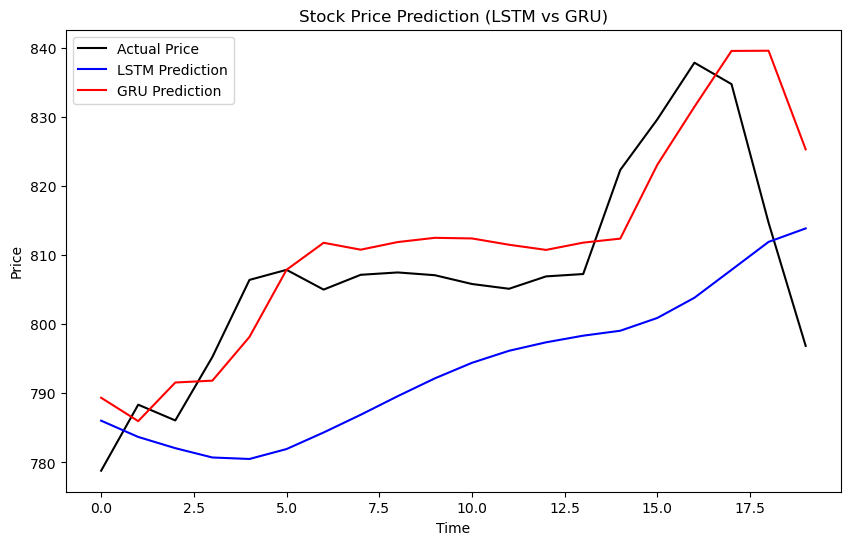

In [24]:
plt.figure(figsize=(10,6))

plt.plot(real_stock_price, color='black', label='Actual Price')
plt.plot(pred_lstm, color='blue', label='LSTM Prediction')
plt.plot(pred_gru, color='red', label='GRU Prediction')

plt.title("Stock Price Prediction (LSTM vs GRU)")
plt.xlabel("Time")
plt.ylabel("Price")
plt.legend()

plt.show()

In [34]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

# RMSE
lstm_rmse = np.sqrt(mean_squared_error(real_stock_price, pred_lstm))
print("🔹 LSTM RMSE:", lstm_rmse)

# MAE
lstm_mae = mean_absolute_error(real_stock_price, pred_lstm)
print("🔹 LSTM MAE:", lstm_mae)

# MAPE
lstm_mape = np.mean(np.abs((real_stock_price - pred_lstm) / real_stock_price)) * 100
print("🔹 LSTM MAPE:", lstm_mape, "%")

# Accuracy
lstm_accuracy = 100 - lstm_mape
print("🔹 LSTM Accuracy:", lstm_accuracy, "%")

🔹 LSTM RMSE: 18.62974226726271
🔹 LSTM MAE: 16.366781982421873
🔹 LSTM MAPE: 2.0131701064357697 %
🔹 LSTM Accuracy: 97.98682989356423 %


In [36]:
# RMSE
gru_rmse = np.sqrt(mean_squared_error(real_stock_price, pred_gru))
print("\n🔹 GRU RMSE:", gru_rmse)

# MAE
gru_mae = mean_absolute_error(real_stock_price, pred_gru)
print("🔹 GRU MAE:", gru_mae)

# MAPE
gru_mape = np.mean(np.abs((real_stock_price - pred_gru) / real_stock_price)) * 100
print("🔹 GRU MAPE:", gru_mape, "%")

# Accuracy
gru_accuracy = 100 - gru_mape
print("🔹 GRU Accuracy:", gru_accuracy, "%")


🔹 GRU RMSE: 10.211639812371097
🔹 GRU MAE: 7.62885229492187
🔹 GRU MAPE: 0.9456312441443969 %
🔹 GRU Accuracy: 99.0543687558556 %


In [38]:
# ================================
# Predict Next Day using LSTM & GRU
# ================================

# Get last 60 days
last_60_days = dataset_total[len(dataset_total) - 60:].values
last_60_days = last_60_days.reshape(-1, 1)

# Scale the data
last_60_days_scaled = scaler.transform(last_60_days)

# Prepare input
X_future = []
X_future.append(last_60_days_scaled[:, 0])
X_future = np.array(X_future)

# Reshape for RNN
X_future = np.reshape(X_future, (X_future.shape[0], X_future.shape[1], 1))

# -------------------------------
# LSTM Prediction
# -------------------------------
pred_lstm = model_lstm.predict(X_future)
pred_lstm = scaler.inverse_transform(pred_lstm)

# -------------------------------
# GRU Prediction
# -------------------------------
pred_gru = model_gru.predict(X_future)
pred_gru = scaler.inverse_transform(pred_gru)

# -------------------------------
# Print Results
# -------------------------------
print("📊 Next Day Stock Prediction")
print("-----------------------------------")
print(f"LSTM Prediction: {pred_lstm[0][0]:.2f}")
print(f"GRU Prediction : {pred_gru[0][0]:.2f}")

# -------------------------------
# Optional: Compare with actual (if available)
# -------------------------------
try:
    actual_price = real_stock_price[0][0]
    
    print("\nActual Price:", actual_price)
    print(f"LSTM Error: {abs(actual_price - pred_lstm[0][0]):.2f}")
    print(f"GRU Error : {abs(actual_price - pred_gru[0][0]):.2f}")
    
    if abs(actual_price - pred_lstm[0][0]) < abs(actual_price - pred_gru[0][0]):
        print("\n✔ LSTM is more accurate")
    else:
        print("\n✔ GRU is more accurate")

except:
    print("\n⚠ Actual value not available for comparison")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step
📊 Next Day Stock Prediction
-----------------------------------
LSTM Prediction: 812.89
GRU Prediction : 808.63

Actual Price: 778.81
LSTM Error: 34.08
GRU Error : 29.82

✔ GRU is more accurate
